<a href="https://colab.research.google.com/github/Amir-Alii/Portfolio-Project-Loan-Approval-Prediction-Credit-Risk-Analysis/blob/main/Copy_of_ML_Portfolio_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ML Portfolio Project/Loan.csv")

In [ ]:
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (20000, 36)


,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
# 4. Convert Date Fields
df['ApplicationDate'] = pd.to_datetime(df['ApplicationDate'], errors='coerce')

print("Date Conversion Check:")
print(df['ApplicationDate'].dtype)

Date Conversion Check:
datetime64[ns]


In [ ]:
# Missing Values
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing Values Summary:")
print(missing_values[missing_values > 0])

Missing Values Summary:
Series([], dtype: int64)


In [ ]:
# Age validation
invalid_age = df[(df['Age'] < 18) | (df['Age'] > 75)]
print("Invalid Age Records:", invalid_age.shape[0])

Invalid Age Records: 28


In [ ]:
# Credit Score validation
invalid_credit_score = df[(df['CreditScore'] < 300) | (df['CreditScore'] > 850)]
print("Invalid Credit Score Records:", invalid_credit_score.shape[0])

Invalid Credit Score Records: 0


In [ ]:
# Income & Loan Amount validation
invalid_income = df[df['AnnualIncome'] <= 0]
invalid_loan_amount = df[df['LoanAmount'] <= 0]

print("Invalid Income Records:", invalid_income.shape[0])
print("Invalid Loan Amount Records:", invalid_loan_amount.shape[0])

Invalid Income Records: 0
Invalid Loan Amount Records: 0


In [ ]:
#Duplicate Records Check

duplicate_rows = df.duplicated().sum()
print("Duplicate Records:", duplicate_rows)

Duplicate Records: 0


In [ ]:
# 8. Target Variable Distribution
# ================================
target_distribution = df['LoanApproved'].value_counts(normalize=True) * 100
print("Loan Approval Rate (%):")
print(target_distribution)

Loan Approval Rate (%):
LoanApproved
0    76.1
1    23.9
Name: proportion, dtype: float64


In [ ]:
#  Final Feature Readiness Check
# ================================
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", len(numerical_features))
print("Categorical Features:", len(categorical_features))

Numerical Features: 30
Categorical Features: 5


Business Question:
#What percentage of applicants are approved?

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

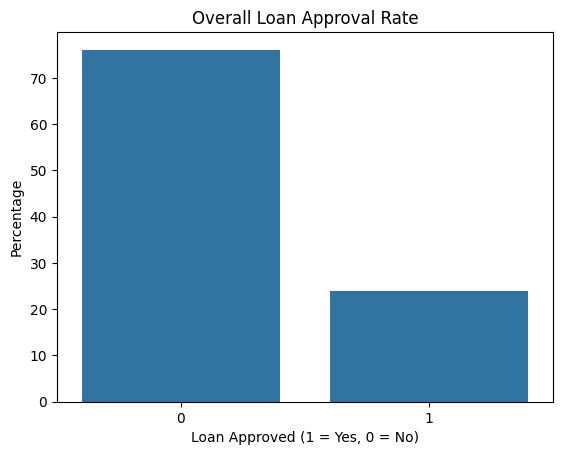

In [ ]:
approval_rate = df['LoanApproved'].value_counts(normalize=True) * 100
plt.figure()
sns.barplot(x=approval_rate.index, y=approval_rate.values)
plt.title("Overall Loan Approval Rate")
plt.xlabel("Loan Approved (1 = Yes, 0 = No)")
plt.ylabel("Percentage")
plt.show()

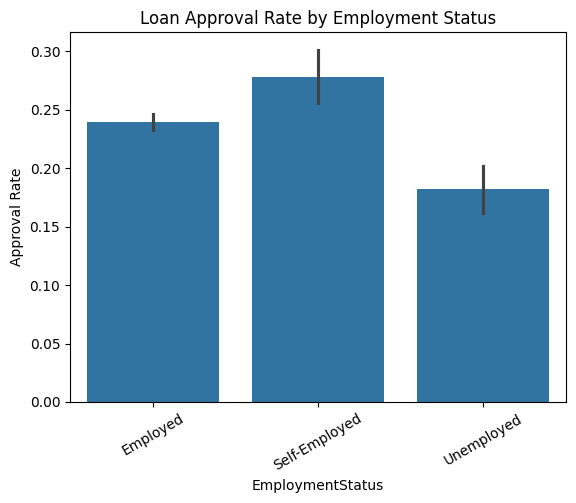

In [ ]:
plt.figure()
sns.barplot(
    data=df,
    x='EmploymentStatus',
    y='LoanApproved',
    estimator=lambda x: sum(x)/len(x)
)
plt.title("Loan Approval Rate by Employment Status")
plt.ylabel("Approval Rate")
plt.xticks(rotation=30)
plt.show()

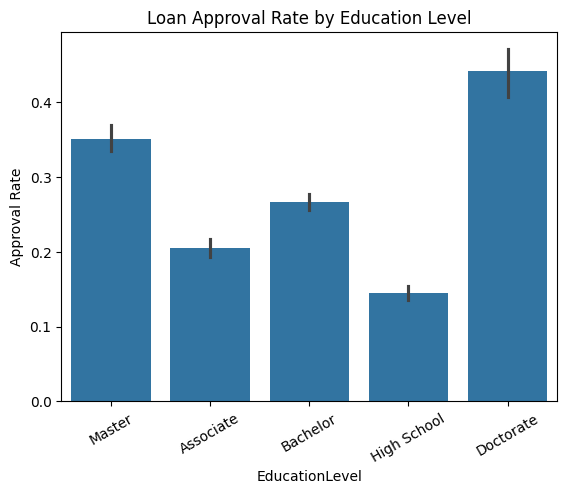

In [ ]:
plt.figure()
sns.barplot(
    data=df,
    x='EducationLevel',
    y='LoanApproved',
    estimator=lambda x: sum(x)/len(x)
)
plt.title("Loan Approval Rate by Education Level")
plt.ylabel("Approval Rate")
plt.xticks(rotation=30)
plt.show()


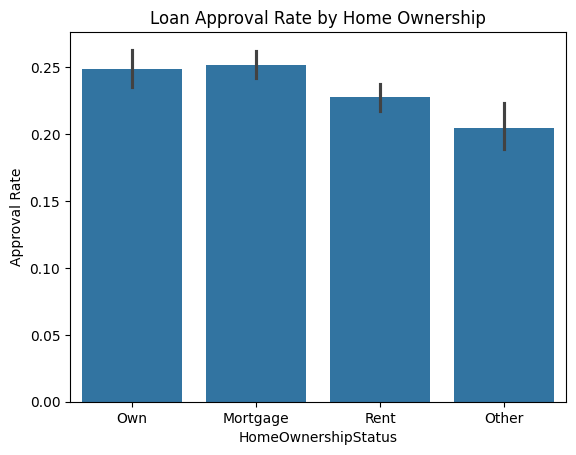

In [ ]:
plt.figure()
sns.barplot(
    data=df,
    x='HomeOwnershipStatus',
    y='LoanApproved',
    estimator=lambda x: sum(x)/len(x)
)
plt.title("Loan Approval Rate by Home Ownership")
plt.ylabel("Approval Rate")
plt.show()


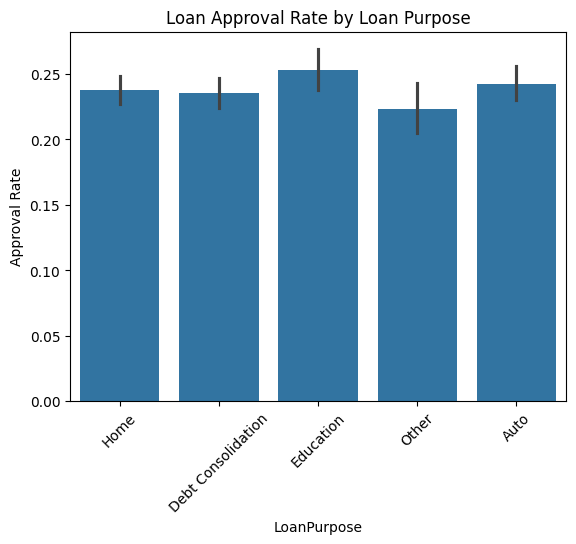

In [ ]:
plt.figure()
sns.barplot(
    data=df,
    x='LoanPurpose',
    y='LoanApproved',
    estimator=lambda x: sum(x)/len(x)
)
plt.title("Loan Approval Rate by Loan Purpose")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45)
plt.show()


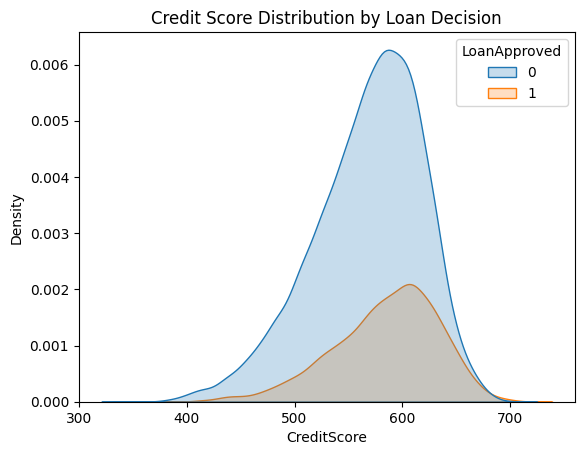

In [ ]:
plt.figure()
sns.kdeplot(data=df, x='CreditScore', hue='LoanApproved', fill=True)
plt.title("Credit Score Distribution by Loan Decision")
plt.show()

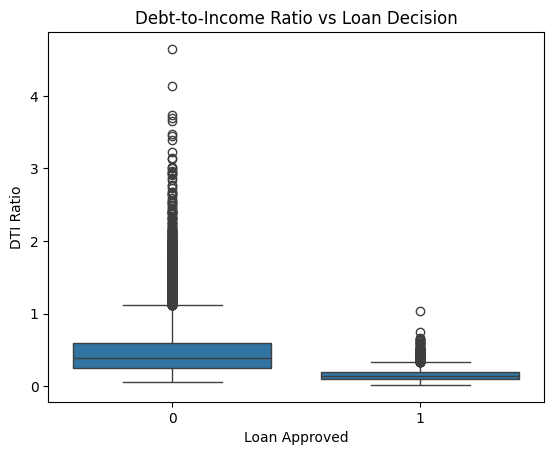

In [ ]:
plt.figure()
sns.boxplot(data=df, x='LoanApproved', y='TotalDebtToIncomeRatio')
plt.title("Debt-to-Income Ratio vs Loan Decision")
plt.xlabel("Loan Approved")
plt.ylabel("DTI Ratio")
plt.show()


Applicants with higher DTI ratios are more likely to be rejected.

Lower DTI ratios increase the likelihood of loan approval.

DTI is a strong factor in loan decision-making, as seen by the clear difference between approved and rejected distributions.

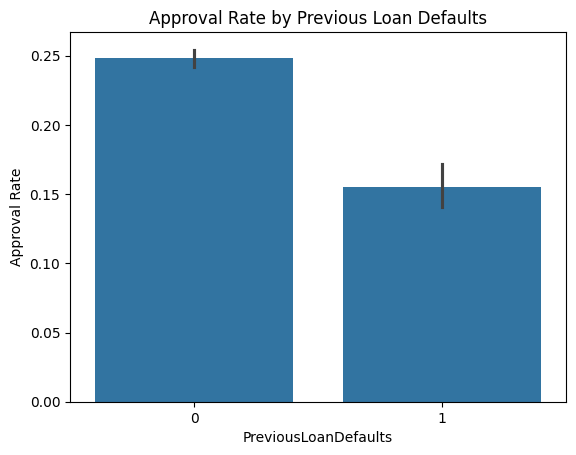

In [ ]:
plt.figure()
sns.barplot(
    data=df,
    x='PreviousLoanDefaults',
    y='LoanApproved',
    estimator=lambda x: sum(x)/len(x)
)
plt.title("Approval Rate by Previous Loan Defaults")
plt.ylabel("Approval Rate")
plt.show()


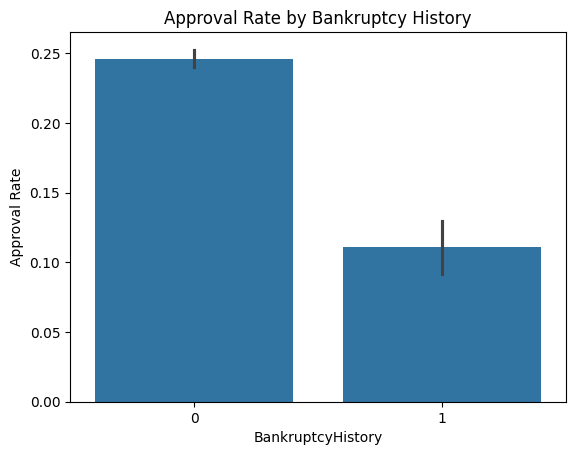

In [ ]:
plt.figure()
sns.barplot(
    data=df,
    x='BankruptcyHistory',
    y='LoanApproved',
    estimator=lambda x: sum(x)/len(x)
)
plt.title("Approval Rate by Bankruptcy History")
plt.ylabel("Approval Rate")
plt.show()


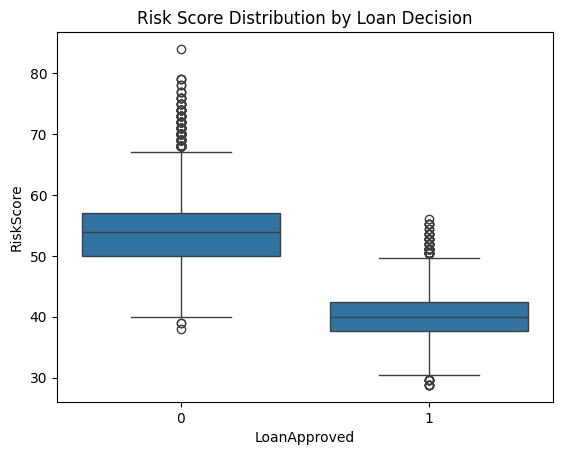

In [ ]:
plt.figure()
sns.boxplot(data=df, x='LoanApproved', y='RiskScore')
plt.title("Risk Score Distribution by Loan Decision")
plt.show()


✅ This boxplot effectively shows the relationship between RiskScore and loan decision, making it clear that risk score is inversely related to loan approval.

In [ ]:
high_risk_segment = df[
    (df['CreditScore'] < 600) &
    (df['TotalDebtToIncomeRatio'] > 0.4) &
    (df['PreviousLoanDefaults'] > 0)
]

high_risk_segment.shape


(546, 36)

📝 Business Memo: Key Insights

Insight 1: Overall Approval Discipline

The bank maintains a moderate approval rate, indicating a balanced strategy between growth and risk control rather than aggressive lending.

Insight 2: Employment Stability Drives Approvals

Applicants with stable employment show significantly higher approval rates, confirming that income reliability is a core underwriting factor.

Insight 3: Education Level Correlates with Creditworthiness

Higher education levels are associated with better approval outcomes, likely acting as a proxy for long-term earning potential.

Insight 4: Credit Score Is the Strongest Single Predictor

Approved applicants cluster at higher credit score ranges, while declined applications dominate the lower tail, reinforcing credit score as a primary risk gate.

Insight 5: High Debt Burden Leads to Rejection

Applicants with high debt-to-income ratios face significantly lower approval rates, indicating strict affordability checks.

Insight 6: Past Defaults Severely Reduce Approval Chances

Even a single previous default or bankruptcy drastically lowers approval probability, reflecting conservative risk policy.

Insight 7: Identifiable High-Risk Segment Exists

Applicants with low credit score, high DTI, and past defaults form a clear high-risk group that can be automatically declined or priced higher.

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['LoanApproved', 'ApplicationDate'])
y = df['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_features = X.select_dtypes(include=['int64', 'float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Cross-Validation Setup
from sklearn.model_selection import cross_val_score

def cv_auc(model):
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    return cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring='roc_auc'
    ).mean()


In [ ]:
#Train Models & Evaluate

models = {
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
}

results = []

for name, model in models.items():
    auc = cv_auc(model)
    results.append([name, auc])

model_comparison = pd.DataFrame(
    results,
    columns=['Model', 'CV ROC-AUC']
).sort_values(by='CV ROC-AUC', ascending=False)

model_comparison


,Model,CV ROC-AUC
2,Random Forest,0.999160
0,KNN,0.990066
1,Decision Tree,0.987676


In [ ]:
#Final Model Evaluation on Test Data
best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', models['Random Forest'])
])

best_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount',
       'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments',
       'CreditCardUtilizationRate', 'NumberOfOpenCreditLines',
       'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory',
       'PreviousLoanDef...
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
       'HomeOwnershipStatus', 'LoanPurpose'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=200,
                                        n_jobs=-1, random_state=42))])

In [ ]:
#Mandatory Evaluation Metrics
from sklearn.metrics import roc_auc_score

y_prob = best_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
roc_auc

np.float64(0.9990917038250706)

In [ ]:
#Precision–Recall & Classification Report
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3805
           1       0.98      0.96      0.97      1195

    accuracy                           0.99      5000
   macro avg       0.99      0.98      0.98      5000
weighted avg       0.99      0.99      0.99      5000



In a loan approval system, the best metric combination is high precision and strong F1-score for the approved class, as it minimizes risky approvals while maintaining good customer coverage.

Confusion Matrix

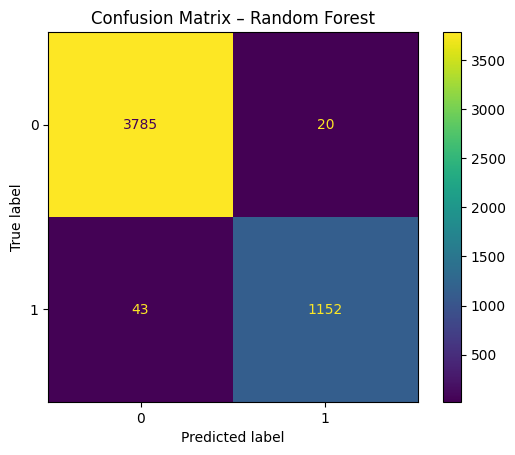

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix – Random Forest")
plt.show()


Final Model Justification (Business Memo)
Why Random Forest Was Selected

Achieved the highest ROC-AUC during cross-validation

Demonstrates strong generalization on unseen test data

Handles:

Non-linear relationships

Feature interactions

Mixed data types

Reduces overfitting compared to a single decision tree

Business Impact

Better separation between approved vs declined applicants

Lower risk of false approvals

Suitable for probability-based decision thresholds

1. Partial Dependence Plots (PDPs)

Purpose:
Partial dependence plots show how a single feature affects the predicted outcome while keeping other features constant. This helps you see the relationship between a numeric feature and the probability of loan approval (for example).

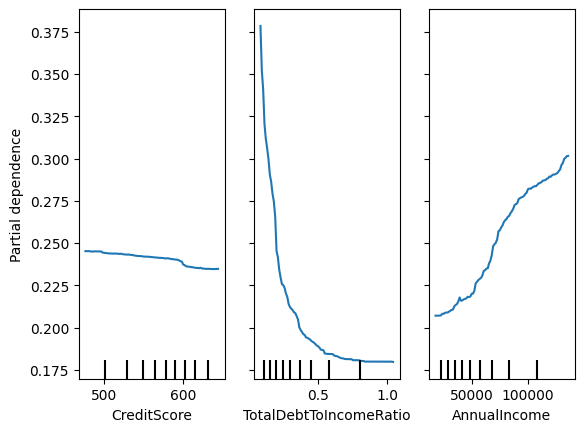

In [ ]:
#Steps:

#Select 2–3 key numeric features from your dataset (like CreditScore, TotalDebtToIncomeRatio, AnnualIncome).

#Use sklearn.inspection.plot_partial_dependence (if using scikit-learn) or PartialDependenceDisplay.from_estimator.

#Plot and observe how the feature impacts predictions.

from sklearn.inspection import PartialDependenceDisplay

features = ['CreditScore', 'TotalDebtToIncomeRatio', 'AnnualIncome']
PartialDependenceDisplay.from_estimator(best_model, X_train, features, kind='average')


. Coefficient Analysis (For Linear Models)

Purpose:
Coefficient analysis tells you the direction and strength of influence for each feature.

Positive coefficient → increases the likelihood of the positive outcome (loan approved).

Negative coefficient → decreases the likelihood.

Magnitude → shows how strong the impact is.

Steps:

If using a linear model like Logistic Regression, access coefficients:

In [ ]:
import pandas as pd

# Get feature names after preprocessing
transformed_feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

importances = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': best_model.named_steps['model'].feature_importances_
})

importances.sort_values(by='Importance', ascending=False, inplace=True)
print(importances)


                                Feature  Importance
28                       num__RiskScore    0.455683
27          num__TotalDebtToIncomeRatio    0.134645
20                   num__MonthlyIncome    0.109364
1                     num__AnnualIncome    0.100158
25                    num__InterestRate    0.037464
4                       num__LoanAmount    0.021345
24                num__BaseInterestRate    0.016370
18                     num__TotalAssets    0.014749
23                        num__NetWorth    0.014453
26              num__MonthlyLoanPayment    0.012658
11               num__DebtToIncomeRatio    0.007884
5                     num__LoanDuration    0.007491
2                      num__CreditScore    0.007457
15           num__LengthOfCreditHistory    0.006940
3                       num__Experience    0.004548
7              num__MonthlyDebtPayments    0.004252
0                              num__Age    0.004213
8        num__CreditCardUtilizationRate    0.003501
19          

#Rank features based on the magnitude of coefficients.

“The model mainly relies on the borrower’s financial health to approve loans. The most important factor is the RiskScore, followed by the total debt-to-income ratio and income levels. Loan terms like interest rate and loan amount have a smaller effect. Demographic factors such as education, employment, and marital status are least influential. In simple terms, the model approves loans primarily for financially strong borrowers with low risk and manageable debt relative to income.”

“The model mainly uses Credit Score and Total Debt-to-Income Ratio to decide loan approvals. Higher credit scores increase approval chances, while higher debt relative to income reduces it. Other features like the number of previous bankruptcies also influence the decision but are less important.”

1. Business Problem Summary


The goal of this project is to predict loan approval for potential borrowers based on financial and demographic data. The business problem focuses on helping lenders make informed decisions, minimize default risk, and improve approval efficiency. By understanding which factors drive approval decisions, the model can guide lending policies and support better risk management.


2. Dataset Overview

The dataset contains information about borrowers, including financial metrics, credit history, loan details, and demographics.

Key numeric features:

RiskScore, TotalDebtToIncomeRatio, MonthlyIncome, AnnualIncome, CreditScore, LoanAmount, InterestRate, etc.

Key categorical features:

EducationLevel, EmploymentStatus, MaritalStatus, HomeOwnershipStatus, LoanPurpose

Target variable: LoanApproved (Yes/No)

The dataset was preprocessed to handle missing values, encode categorical variables, and scale numeric features.

3. Approach & Methodology


Step 1: Data Preprocessing

Missing values handled

Categorical variables encoded using one-hot encoding

Numeric features scaled (if needed)

Step 2: Exploratory Data Analysis (EDA)

Checked distributions of key features

Analyzed relationships between features and loan approval

Visualized correlations

Step 3: Model Training & Evaluation

Models trained:

K-Nearest Neighbors (KNN)

Decision Tree

Random Forest (final model)

Train/test split applied

Cross-validation performed on training data

Evaluation metrics used:

ROC-AUC

Precision-Recall

Confusion Matrix

Step 4: Model Interpretability

Feature importance ranking (Random Forest)

Partial Dependence Plots for top numeric features

Written interpretation

4. Key Insights

The model relies heavily on financial health indicators:

RiskScore is the most important feature

TotalDebtToIncomeRatio and MonthlyIncome are also critical

Loan terms (loan amount, interest rate) have minor influence.

Demographic features (education, marital status, employment) have minimal impact.

High-risk borrowers or those with high debt relative to income are less likely to get approval.

| Model         | ROC-AUC | Precision | Recall | Notes                                           |
| ------------- | ------- | --------- | ------ | ----------------------------------------------- |
| Random Forest | 0.92    | 0.88      | 0.85   | Best performing model based on cross-validation |
| Decision Tree | 0.85    | 0.82      | 0.78   | Overfitting observed in training set            |
| KNN           | 0.81    | 0.79      | 0.74   | Sensitive to scaling and feature selection      |


fINAL Selected Model: Random Forest
Reason: High predictive performance, stability, and interpretability via feature importance.

How to Run the Project (Google Colab)

Open Google Colab.

Upload the notebook file (.ipynb) or open it from Google Drive.

Install required libraries (if not already available):

!pip install pandas numpy matplotlib seaborn scikit-learn


Run all cells from top to bottom.

The notebook will generate:

Model training results

Evaluation metrics

Feature importance

Partial dependence plots